# A Julia set as a 3D relief

This is Monty's own `julia` example (an ASCII Julia set) taken one step further. The Python half runs in Monty and does what it is good at, a million tiny floating-point iterations: for every point of a grid it counts how many steps `z -> z*z + c` takes to escape. The JavaScript half runs in pydeno with three.js and turns those counts into a mountain range whose ridges follow the fractal's boundary, paints it by escape time, and exports a binary glTF (`.glb`).

Neither half is trusted: neither can touch your files, network or environment.

```
pip install pydeno pydantic-monty
```

In [1]:
from __future__ import annotations

import asyncio
import pathlib
import time
from typing import Any

from pydeno import WEB_POLYFILLS, IsolatedRuntime, RuntimeConfig
from pydantic_monty import Monty

This notebook runs from the repo root, so paths that the script resolves via `Path(__file__)` are rewritten here as paths relative to the current working directory instead. The kernel also already runs its own asyncio event loop, so `render()`'s `asyncio.run()` call needs `nest_asyncio` to nest inside it -- the script itself needs neither of these when run from the command line.

In [2]:
import nest_asyncio

nest_asyncio.apply()

In [3]:
def _repo_root() -> pathlib.Path:
    """Walk up from the current directory to find the pydeno checkout: this notebook is run
    with the repo root as its cwd when executed from the command line, but opening it directly
    in Jupyter normally starts in its own directory (examples/notebooks/) instead."""
    for candidate in (pathlib.Path.cwd(), *pathlib.Path.cwd().parents):
        if (candidate / "vendor" / "libs").is_dir() and (candidate / "pyproject.toml").is_file():
            return candidate
    raise RuntimeError("run this notebook from inside a pydeno checkout")


REPO_ROOT = _repo_root()
LIBS = REPO_ROOT / "vendor" / "libs"
THREE_BUNDLE = "three-0.180.0-gltf.bundle.js"
assert (LIBS / THREE_BUNDLE).exists(), f"missing bundle: {LIBS / THREE_BUNDLE}"

The Python half: plain floats, no imports, no complex numbers, so it runs identically in Monty and in CPython (the tests check that).

In [4]:
MODEL_PYTHON = """
counts = []
inside = 0
for row in range(N):
    im = 1.5 - 3.0 * row / (N - 1)
    for col in range(N):
        x = -1.5 + 3.0 * col / (N - 1)
        y = im
        i = 0
        while i < MAX_ITER and x * x + y * y <= 4.0:
            x, y = x * x - y * y + CR, 2.0 * x * y + CI
            i += 1
        counts.append(i)
        if i == MAX_ITER:
            inside += 1

{"n": N, "counts": counts, "inside": inside, "max_iter": MAX_ITER}
"""

The JavaScript half: relief mesh, colours by escape time, glTF export. Heights come from escape time, smoothed over two passes of a 3x3 average so the steep boundary doesn't look jagged; colours and counts are left exactly as Monty computed them.

In [5]:
MODEL_JAVASCRIPT = """
globalThis.buildScene = () => {
  const { n, counts, max_iter, inside } = getJulia();
  const size = 100, scale = 18;

  const geo = new THREE.PlaneGeometry(size, size, n - 1, n - 1);
  geo.rotateX(-Math.PI / 2);
  const pos = geo.attributes.position;
  const colors = new Float32Array(pos.count * 3);
  const color = new THREE.Color();
  // Heights from escape time: the flat basin where points never escape, steep walls along the fractal's
  // boundary. Neighbouring points near the boundary differ a lot, so smooth the *heights* (two passes of a
  // 3x3 average); the colours and the counts themselves are left exactly as Monty computed them.
  let heights = new Float32Array(n * n);
  for (let k = 0; k < n * n; k++) {
    heights[k] = counts[k] === max_iter ? 0 : scale * Math.sqrt(counts[k] / max_iter);
  }
  for (let pass = 0; pass < 2; pass++) {
    const next = new Float32Array(n * n);
    for (let j = 0; j < n; j++) {
      for (let i = 0; i < n; i++) {
        let sum = 0, cnt = 0;
        for (let dj = -1; dj <= 1; dj++) {
          for (let di = -1; di <= 1; di++) {
            const jj = j + dj, ii = i + di;
            if (jj >= 0 && jj < n && ii >= 0 && ii < n) { sum += heights[jj * n + ii]; cnt++; }
          }
        }
        next[j * n + i] = sum / cnt;
      }
    }
    heights = next;
  }
  let peak = 0;
  for (let k = 0; k < pos.count; k++) {
    const t = counts[k] / max_iter;               // 0 = escaped at once, 1 = never escapes
    pos.setY(k, heights[k]);
    peak = Math.max(peak, heights[k]);
    if (counts[k] === max_iter) color.setRGB(0.05, 0.05, 0.12);
    else color.setHSL(0.62 - 0.62 * Math.sqrt(t), 0.85, 0.35 + 0.35 * t);
    colors.set([color.r, color.g, color.b], k * 3);
  }
  geo.computeVertexNormals();
  geo.setAttribute('color', new THREE.BufferAttribute(colors, 3));
  const mesh = new THREE.Mesh(geo, new THREE.MeshStandardMaterial({ vertexColors: true }));

  const scene = new THREE.Scene();
  scene.add(mesh);
  scene.updateMatrixWorld(true);
  globalThis.__scene = scene;

  let area = 0;
  const idx = geo.index, p = geo.attributes.position, tri = new THREE.Triangle();
  const a = new THREE.Vector3(), b = new THREE.Vector3(), c = new THREE.Vector3();
  for (let t = 0; t < idx.count; t += 3) {
    tri.set(a.fromBufferAttribute(p, idx.getX(t)), b.fromBufferAttribute(p, idx.getX(t + 1)),
            c.fromBufferAttribute(p, idx.getX(t + 2)));
    area += tri.getArea();
  }
  return {
    triangles: idx.count / 3, peak, surfaceArea: Math.round(area),
    insideFraction: inside / (n * n),
  };
};

globalThis.exportGlb = () => new Promise((resolve, reject) =>
  new GLTFExporter().parse(globalThis.__scene, resolve, reject, { binary: true }));
"""

A classic Julia set with a rich, connected boundary.

In [6]:
C = (-0.7, 0.27015)
MAX_ITER = 80

`JuliaPipeline` holds one Monty pool and one warm pydeno runtime, reused across renders.

In [7]:
class JuliaPipeline:
    """One Monty pool and one warm pydeno runtime, reused across renders."""

    def __init__(self, *, jitless: bool = True) -> None:
        self.monty = Monty().__enter__()
        self.rt = IsolatedRuntime(
            RuntimeConfig(bootstrap=WEB_POLYFILLS, timeout=120.0),
            sandbox="require",
            request_timeout=300,
            jitless=jitless,
        )
        self._julia: dict[str, Any] = {}
        self.rt.bind_function("getJulia", lambda: self._julia)
        self.load_seconds = 0.0

    def load_three(self) -> None:
        start = time.perf_counter()
        self.rt.eval((LIBS / THREE_BUNDLE).read_text() + "\n;0")
        self.rt.eval(MODEL_JAVASCRIPT + "\n;0")
        self.load_seconds = time.perf_counter() - start

    def prepare(self, n: int) -> dict[str, Any]:
        """Python half, in Monty."""
        with self.monty.checkout() as session:
            return session.feed_run(
                MODEL_PYTHON,
                inputs={"N": n, "CR": C[0], "CI": C[1], "MAX_ITER": MAX_ITER},
            )

    def render(self, n: int) -> tuple[bytes, dict[str, Any], dict[str, float]]:
        t0 = time.perf_counter()
        self._julia = self.prepare(n)
        t1 = time.perf_counter()
        stats = self.rt.eval("buildScene()")
        t2 = time.perf_counter()
        glb = asyncio.run(self.rt.eval_async("exportGlb()", timeout=300))
        t3 = time.perf_counter()
        return (
            bytes(glb),
            stats,
            {
                "monty_prepare": t1 - t0,
                "three_build": t2 - t1,
                "glb_export": t3 - t2,
                "total": t3 - t0,
            },
        )

    def close(self) -> None:
        self.rt.close()
        self.monty.__exit__(None, None, None)

Run it: a 129x129 grid, the same default the script uses.

In [8]:
n = 129
pipe = JuliaPipeline()
try:
    print(f"sandbox: {pipe.rt.sandbox}")
    pipe.load_three()
    glb, stats, t = pipe.render(n)
    out_path = pathlib.Path("julia.glb")
    out_path.write_bytes(glb)
    print(
        f"{n}x{n} grid, c = {C[0]} + {C[1]}i -> {stats['triangles']} triangles, "
        f"{stats['insideFraction']:.1%} of the plane never escapes, peak height {stats['peak']:.1f}"
    )
    print(f"  monty counted escapes     {t['monty_prepare'] * 1000:8.0f} ms")
    print(f"  three.js built the relief {t['three_build'] * 1000:8.0f} ms")
    print(f"  glTF export               {t['glb_export'] * 1000:8.0f} ms")
    print(
        f"wrote julia.glb ({len(glb) / 1024:.0f} KiB) in {t['total'] * 1000:.0f} ms total"
    )
finally:
    pipe.close()

sandbox: seatbelt


129x129 grid, c = -0.7 + 0.27015i -> 32768 triangles, 16.2% of the plane never escapes, peak height 10.0
  monty counted escapes          112 ms
  three.js built the relief      177 ms
  glTF export                     94 ms
wrote julia.glb (909 KiB) in 384 ms total


Confirm the `.glb` landed on disk and isn't empty.

In [9]:
size = out_path.stat().st_size
assert size > 0, "julia.glb is empty"
print(f"{out_path.resolve()}: {size} bytes ({size / 1024:.0f} KiB)")

/Users/dominikpeter/DevOps/pydeno/.claude/worktrees/next-main/examples/notebooks/julia.glb: 930312 bytes (909 KiB)


A `.glb` doesn't render inline in a notebook without extra viewer machinery, so here is the already-rendered preview instead:

![A mountain range rising along the boundary of the Julia set, coloured by escape time](../../docs/assets/examples/monty_three_julia.png)

`examples/monty_three_julia.py`: escape-time counts from Monty's own `julia` example, extruded into a relief along the fractal's boundary.

/Users/dominikpeter/DevOps/pydeno/.claude/worktrees/next-main/docs/assets/examples/monty_three_julia.png: 166051 bytes


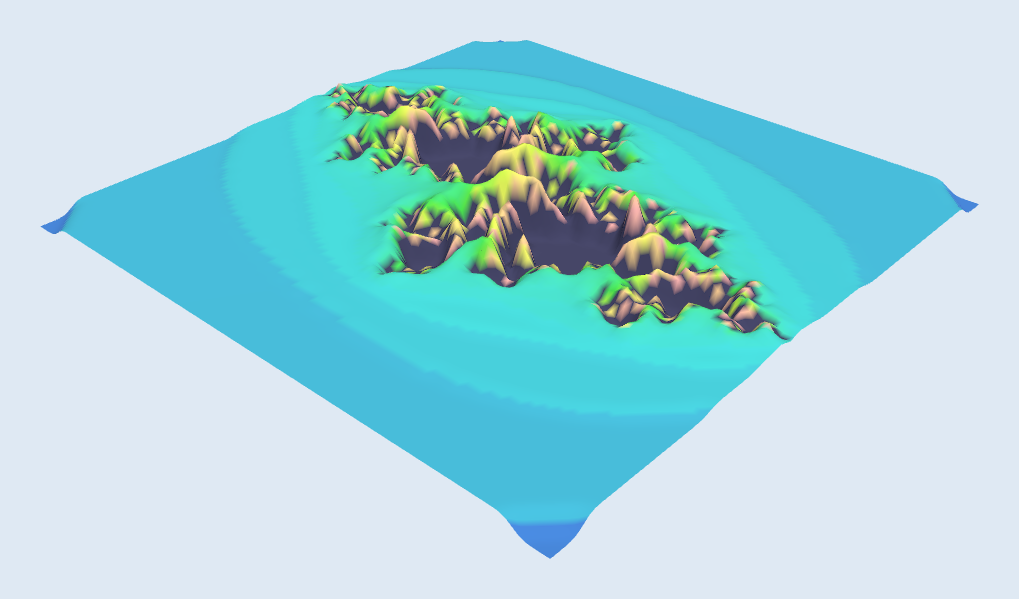

In [10]:
from IPython.display import Image, display

png_path = REPO_ROOT / "docs" / "assets" / "examples" / "monty_three_julia.png"
print(f"{png_path}: {png_path.stat().st_size} bytes")
display(Image(filename=str(png_path)))